# BikeFlow — Lag Features Experiment

本 Notebook 研究一个问题：**已发生的骑行需求，能否帮助预测下一个小时的需求？**沿用 03 的 One-Hot 时间特征、四个天气字段、`LinearRegression` 和固定测试时段，只比较三种历史需求 Lag Feature 的贡献。

**本次运行速览：**在同一测试时段，V1 的 MAE 为 1,513.90，三个 lag 一起使用时为 745.08（降低 50.78%）；单独加入时 `lag_1` 的 MAE 最低。第 13–20 节给出完整指标、通勤高峰和局限。

数据来自 `data/processed/bikeflow_2024.csv`；处理依据为 `src/data/clean_citibike.py`、`build_hourly_demand.py`、`download_weather.py`、`build_model_dataset.py`。V1 的设置以 `notebooks/03_improved_baseline.ipynb` 为准。所有结果均来自本 Notebook 的实际运行。


## 1. Experiment Goal

这是一个 **Ablation Experiment（消融实验）**：先复现不含 lag 的 V1，再分别只加入 `lag_1`、`lag_24`、`lag_168`，最后三个一起加入。五个模型都用同一个测试集、同一算法；比较 MAE、RMSE、R²、高峰误差和负预测值。

**预测口径：**逐小时滚动预测（one-step / rolling historical feature assumption）。预测时，之前已发生小时的真实 `ride_count` 可用。当前天气字段沿用 V1 的历史观测，因此这里是回顾性实验；真正提前预测未来小时，需要相应可获得的天气预报。


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({"figure.figsize": (12, 4.8), "font.size": 10, "axes.grid": False})


## 2. Load Dataset

读取与 02、03 相同的已处理数据。`timestamp` 是纽约本地钟表时间，一行代表一个小时标签。


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("请从 BikeFlow 项目根目录或 notebooks 目录运行")

data = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
print(f"数据文件: {DATA_PATH}")
print(f"原始维度: {data.shape}")
print(f"时间范围: {data['timestamp'].min()} 至 {data['timestamp'].max()}")
print(f"重复 timestamp: {data['timestamp'].duplicated().sum()}")
display(data.head(3))


数据文件: C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
原始维度: (8784, 10)
时间范围: 2024-01-01 00:00:00 至 2024-12-31 23:00:00
重复 timestamp: 0


,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2024-01-01 00:00:00,1901,1.8,-2.1,71.0,0.0,0.0,0.0,3.0,9.0
1,2024-01-01 01:00:00,2333,2.4,-1.7,71.0,0.0,0.0,0.0,3.0,10.9
2,2024-01-01 02:00:00,1939,2.4,-1.5,73.0,0.0,0.0,0.0,3.0,10.1


## 3. Prepare Base Features

与 03 完全一致：建模时排除不存在的春季 `2024-03-10 02:00` 和合并了两个真实小时的秋季 `2024-11-03 01:00`。原始表先按时间排序；建模行提取 `hour`、`day_of_week`、`month`。**先从完整的 V1 建模行计算 80/20 边界**，后面删除 lag 空值时不重新切分。


In [3]:
SPRING_GAP = pd.Timestamp("2024-03-10 02:00")
FALL_REPEAT = pd.Timestamp("2024-11-03 01:00")
spring_row = data.loc[data["timestamp"].eq(SPRING_GAP)]
fall_row = data.loc[data["timestamp"].eq(FALL_REPEAT)]
assert len(spring_row) == len(fall_row) == 1
assert spring_row["ride_count"].iloc[0] == 0
assert spring_row.drop(columns=["timestamp", "ride_count"]).isna().all(axis=None)

# 原始表先按时间排序，保留完整钟表小时序列供第 5 节构造 Lag。
data = data.sort_values("timestamp").reset_index(drop=True)
assert not data["timestamp"].duplicated().any()
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()

# 与 V1 一样，只从建模样本中排除两个夏令时特殊标签。
normal_hour_mask = ~data["timestamp"].isin([SPRING_GAP, FALL_REPEAT])
model_data = data.loc[normal_hour_mask].copy().reset_index(drop=True)
model_data["hour"] = model_data["timestamp"].dt.hour
model_data["day_of_week"] = model_data["timestamp"].dt.dayofweek
model_data["month"] = model_data["timestamp"].dt.month

# 在构造 Lag、删除任何 NaN 之前，确定与 03 V1 相同的测试边界。
split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data["timestamp"].iloc[split_index]
print(f"V1 建模行数: {len(model_data):,}")
print(f"原始 V1 切分位置: {split_index:,}")
print(f"由数据算出的固定 Test start: {fixed_test_start}")


V1 建模行数: 8,782
原始 V1 切分位置: 7,025
由数据算出的固定 Test start: 2024-10-19 18:00:00


基础特征继续使用 V1 的 `hour`、`day_of_week`、`month` One-Hot 编码，以及**完全相同**的四个天气字段。`is_weekend` 不另加，因为星期 dummy 已包含它的信息。训练期没有见过的月份 dummy 不参与模型，因此 11、12 月在测试中落在一月基准类别；这是 V1 原有的时间外推局限。


In [4]:
weather_features = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
]
categorical_time_features = ["hour", "day_of_week", "month"]
lag_columns = ["lag_1", "lag_24", "lag_168"]

assert set(weather_features).issubset(model_data.columns)
assert all(pd.api.types.is_numeric_dtype(model_data[name]) for name in weather_features)
assert model_data[weather_features].notna().all(axis=None)
assert model_data["ride_count"].notna().all()
print(f"V1 天气字段: {weather_features}")


V1 天气字段: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


## 4. What is a Lag Feature?

**Lag Feature（滞后特征）**是把“预测时刻之前已经知道的值”放到当前这一行。假设现在要预测 **2024-06-10 08:00** 的骑行需求：

| 特征 | 使用的历史需求 |
|---|---|
| `lag_1` | 2024-06-10 07:00，上一小时 |
| `lag_24` | 2024-06-09 08:00，通常是昨天同一小时 |
| `lag_168` | 2024-06-03 08:00，通常是上周同一天同一小时 |

它们只看**过去**。时间和天气告诉模型“现在是什么时候、环境怎样”，lag 则告诉模型“最近或相似时段实际骑了多少”。


## 5. Create Lag Features

`shift(k)` 把排好时间的 `ride_count` 向下移动 *k* 行。先在**完整的 8,784 个连续本地钟表小时标签**上移动，再挑出与 V1 相同的建模行；因此普通日期的 `lag_24`、`lag_168` 对准昨天、上周同一当地时刻。如果先删掉 DST 行再移动，夏令时附近会发生错位。最前面的 *k* 行没有足够历史，因此得到 NaN；这里不填补，也不取任何未来行。

**DST 例外：**春季不存在的 02:00 占位值可能成为少数 lag 的来源；秋季合并的 01:00 也可能成为来源。它们均在当前时刻之前，但并非普通的单个真实小时。本实验保留 V1 的建模行口径，不额外修改或填补数据，并在结论中保留这一限制。


In [5]:
# 原始表已按时间排序，保证 shift() 读取的是历史钟表小时标签。
# 构造上一小时需求。
data["lag_1"] = data["ride_count"].shift(1)
# 构造昨天同一当地钟表小时需求。
data["lag_24"] = data["ride_count"].shift(24)
# 构造上周同一当地钟表小时需求。
data["lag_168"] = data["ride_count"].shift(168)

# Lag 已构造完毕，现在只保留与 03 V1 相同的建模行。
model_data[lag_columns] = data.loc[normal_hour_mask, lag_columns].to_numpy()

display(model_data.loc[[0, 1, 23, 24, 167, 168],
                       ["timestamp", "ride_count", *lag_columns]])


,timestamp,ride_count,lag_1,lag_24,lag_168
0,2024-01-01 00:00:00,1901,NaN,NaN,NaN
1,2024-01-01 01:00:00,2333,1901.0,NaN,NaN
23,2024-01-01 23:00:00,781,1005.0,NaN,NaN
24,2024-01-02 00:00:00,452,781.0,1901.0,NaN
167,2024-01-07 23:00:00,809,1140.0,669.0,NaN
168,2024-01-08 00:00:00,473,809.0,488.0,1901.0


In [6]:
# 展示每种 Lag 在训练期损失的样本数；测试时间边界保持不变。
train_mask = model_data["timestamp"] < fixed_test_start
test_mask = ~train_mask
sample_loss = pd.DataFrame({
    "Model": ["V1 Baseline", "V2-A + lag_1", "V2-B + lag_24",
              "V2-C + lag_168", "V2-D + all lags"],
    "Training rows": [
        int(train_mask.sum()),
        int((train_mask & model_data["lag_1"].notna()).sum()),
        int((train_mask & model_data["lag_24"].notna()).sum()),
        int((train_mask & model_data["lag_168"].notna()).sum()),
        int((train_mask & model_data[lag_columns].notna().all(axis=1)).sum()),
    ],
})
sample_loss["Rows lost vs V1"] = sample_loss["Training rows"].iloc[0] - sample_loss["Training rows"]
display(sample_loss.set_index("Model"))
print("Lag 造成开头样本缺失是时间序列的正常现象；V2-D 损失最前面的 168 个训练小时。")


,Training rows,Rows lost vs V1
Model,,
V1 Baseline,7025,0
V2-A + lag_1,7024,1
V2-B + lag_24,7001,24
V2-C + lag_168,6857,168
V2-D + all lags,6857,168


Lag 造成开头样本缺失是时间序列的正常现象；V2-D 损失最前面的 168 个训练小时。


## 6. Avoiding Target Leakage

**Target Leakage（目标泄漏）**是预测某小时的时候，偷偷用了当时还不可能知道的信息。这样离线测试会虚假地变好。例如 `lag_24 = 昨天同一小时` 是安全的；`future_24 = 明天同一小时` 不安全。本实验的 lag 只引用当前行**之前**的真实 `ride_count`。

测试集也按逐小时滚动情景处理：预测 2024-10-20 08:00 时，10-20 07:00 若已发生，它的真实需求可作为 `lag_1`。测试集内部已发生的真实需求可以用作后续小时的 lag；这不是提前一次性预测整个测试区间。第 20 节再说明长时段预测的不同要求。


In [7]:
# 用一个测试时刻核对：每个 Lag 的来源必须早于预测时刻。
example_time = pd.Timestamp("2024-10-20 08:00")
example_index = data.index[data["timestamp"].eq(example_time)][0]
lag_examples = []
for name, hours_back in [("lag_1", 1), ("lag_24", 24), ("lag_168", 168)]:
    source = data.iloc[example_index - hours_back]
    lag_examples.append({
        "Feature": name,
        "Prediction time": example_time,
        "Source time": source["timestamp"],
        "Source split": "Test (already occurred)" if source["timestamp"] >= fixed_test_start else "Train",
        "Source ride_count": source["ride_count"],
        "Lag value": data.loc[example_index, name],
    })
lag_example_table = pd.DataFrame(lag_examples)
assert (lag_example_table["Source time"] < lag_example_table["Prediction time"]).all()
assert (lag_example_table["Source ride_count"] == lag_example_table["Lag value"]).all()
display(lag_example_table)


,Feature,Prediction time,Source time,Source split,Source ride_count,Lag value
0,lag_1,2024-10-20 08:00:00,2024-10-20 07:00:00,Test (already occurred),1915,1915.0
1,lag_24,2024-10-20 08:00:00,2024-10-19 08:00:00,Train,4408,4408.0
2,lag_168,2024-10-20 08:00:00,2024-10-13 08:00:00,Train,3147,3147.0


## 7. Fixed Time-Based Train/Test Split

03 的 V1 先排除两条 DST 特殊行，再按时间取前 80% 训练、后 20% 测试。本实验已在创建 lag **之前**按相同规则算出 `fixed_test_start`。现在只按这个边界选行：训练期里根据各模型需要删去开头的 lag NaN，测试期仍从同一时间开始。绝不在 `dropna()` 后重新做 80/20 切分。


In [8]:
train_time = model_data.loc[train_mask, "timestamp"]
test_time = model_data.loc[test_mask, "timestamp"]
y_train_full = model_data.loc[train_mask, "ride_count"]
y_test = model_data.loc[test_mask, "ride_count"]

assert train_time.max() < test_time.min()
assert test_time.min() == fixed_test_start
assert model_data.loc[test_mask, lag_columns].notna().all(axis=None)
print(f"Train start: {train_time.min()}")
print(f"Train end:   {train_time.max()}")
print(f"Test start:  {test_time.min()}")
print(f"Test end:    {test_time.max()}")
print(f"V1 Train/Test rows: {len(y_train_full):,} / {len(y_test):,}")

# 与 03 完全相同的类别范围、drop_first 和训练期列筛选。
time_train = model_data.loc[train_mask, categorical_time_features].copy()
time_test = model_data.loc[test_mask, categorical_time_features].copy()
for frame in (time_train, time_test):
    frame["hour"] = pd.Categorical(frame["hour"], categories=range(24))
    frame["day_of_week"] = pd.Categorical(frame["day_of_week"], categories=range(7))
    frame["month"] = pd.Categorical(frame["month"], categories=range(1, 13))

dummy_train = pd.get_dummies(time_train, drop_first=True, dtype=int)
dummy_test = pd.get_dummies(time_test, drop_first=True, dtype=int)
trained_dummy_columns = dummy_train.columns[dummy_train.any(axis=0)]
dummy_train = dummy_train[trained_dummy_columns]
dummy_test = dummy_test[trained_dummy_columns]
assert dummy_train.columns.equals(dummy_test.columns)

# Feature Matrix：所有模型共用这 42 个基础列，仅 Lag 列不同。
base_train = pd.concat([dummy_train, model_data.loc[train_mask, weather_features]], axis=1)
base_test = pd.concat([dummy_test, model_data.loc[test_mask, weather_features]], axis=1)
train_matrix = pd.concat([base_train, model_data.loc[train_mask, lag_columns]], axis=1)
test_matrix = pd.concat([base_test, model_data.loc[test_mask, lag_columns]], axis=1)

base_features = base_train.columns.tolist()
features_lag1 = base_features + ["lag_1"]
features_lag24 = base_features + ["lag_24"]
features_lag168 = base_features + ["lag_168"]
features_all_lags = base_features + lag_columns

assert base_train.columns.equals(base_test.columns)
assert len(base_features) == 42
assert base_train.notna().all(axis=None) and base_test.notna().all(axis=None)
print(f"基础 Feature 数: {len(base_features)} = {len(dummy_train.columns)} 个时间 dummy + {len(weather_features)} 个天气字段")
print(f"所有模型共用的 Test rows: {len(test_matrix):,}")


Train start: 2024-01-01 00:00:00
Train end:   2024-10-19 17:00:00
Test start:  2024-10-19 18:00:00
Test end:    2024-12-31 23:00:00
V1 Train/Test rows: 7,025 / 1,757
基础 Feature 数: 42 = 38 个时间 dummy + 4 个天气字段
所有模型共用的 Test rows: 1,757


In [9]:
feature_matrix_summary = sample_loss.copy()
feature_matrix_summary["Features"] = [
    len(base_features), len(features_lag1), len(features_lag24),
    len(features_lag168), len(features_all_lags)
]
feature_matrix_summary["Test rows"] = len(test_matrix)
display(feature_matrix_summary.set_index("Model")[[
    "Features", "Training rows", "Rows lost vs V1", "Test rows"
]])


,Features,Training rows,Rows lost vs V1,Test rows
Model,,,,
V1 Baseline,42,7025,0,1757
V2-A + lag_1,43,7024,1,1757
V2-B + lag_24,43,7001,24,1757
V2-C + lag_168,43,6857,168,1757
V2-D + all lags,45,6857,168,1757


In [10]:
# 逐模型核对训练起点与共同测试时段。
model_train_masks = [
    train_mask,
    train_mask & model_data["lag_1"].notna(),
    train_mask & model_data["lag_24"].notna(),
    train_mask & model_data["lag_168"].notna(),
    train_mask & model_data[lag_columns].notna().all(axis=1),
]
time_range_rows = []
for model_name, valid_rows in zip(sample_loss["Model"], model_train_masks):
    valid_train_time = model_data.loc[valid_rows, "timestamp"]
    time_range_rows.append({
        "Model": model_name,
        "Train start": valid_train_time.min(),
        "Train end": valid_train_time.max(),
        "Test start": test_time.min(),
        "Test end": test_time.max(),
    })
time_ranges = pd.DataFrame(time_range_rows).set_index("Model")
display(time_ranges)
assert time_ranges["Test start"].nunique() == 1
assert time_ranges["Test end"].nunique() == 1


,Train start,Train end,Test start,Test end
Model,,,,
V1 Baseline,2024-01-01 00:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,2024-12-31 23:00:00
V2-A + lag_1,2024-01-01 01:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,2024-12-31 23:00:00
V2-B + lag_24,2024-01-02 00:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,2024-12-31 23:00:00
V2-C + lag_168,2024-01-08 00:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,2024-12-31 23:00:00
V2-D + all lags,2024-01-08 00:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,2024-12-31 23:00:00


## 8. V1 — One-Hot Baseline

复现 03 的 42 特征 V1。`model.fit()` 只用训练期；`model.predict()` 对固定测试期生成预测。后面的 lag 模型只在这份基础 Feature Matrix 上加列。


In [11]:
X_train_v1 = train_matrix[base_features]
X_test_v1 = test_matrix[base_features]
model_v1 = LinearRegression()
model_v1.fit(X_train_v1, y_train_full)
pred_v1 = model_v1.predict(X_test_v1)
print(f"V1: {X_train_v1.shape[0]:,} 训练行，{X_train_v1.shape[1]} 特征，{len(pred_v1):,} 测试预测")


V1: 7,025 训练行，42 特征，1,757 测试预测

## 9. V2-A — Add lag_1

只增加完整原始小时序列中前 1 个钟表小时的需求，用于研究**短期惯性**。训练期最前面 1 行没有历史值。


In [12]:
valid_lag1_train = train_matrix["lag_1"].notna()
X_train_lag1 = train_matrix.loc[valid_lag1_train, features_lag1]
y_train_lag1 = y_train_full.loc[valid_lag1_train]
X_test_lag1 = test_matrix[features_lag1]
assert X_train_lag1.notna().all(axis=None) and X_test_lag1.notna().all(axis=None)
model_lag1 = LinearRegression()
model_lag1.fit(X_train_lag1, y_train_lag1)
pred_lag1 = model_lag1.predict(X_test_lag1)
print(f"V2-A: {len(y_train_lag1):,} 训练行，{len(features_lag1)} 特征，{len(pred_lag1):,} 测试预测")


V2-A: 7,024 训练行，43 特征，1,757 测试预测


## 10. V2-B — Add lag_24

只增加完整原始小时序列中前 24 个钟表小时的需求，检验**日周期（Daily Seasonality）**的信息价值。


In [13]:
valid_lag24_train = train_matrix["lag_24"].notna()
X_train_lag24 = train_matrix.loc[valid_lag24_train, features_lag24]
y_train_lag24 = y_train_full.loc[valid_lag24_train]
X_test_lag24 = test_matrix[features_lag24]
assert X_train_lag24.notna().all(axis=None) and X_test_lag24.notna().all(axis=None)
model_lag24 = LinearRegression()
model_lag24.fit(X_train_lag24, y_train_lag24)
pred_lag24 = model_lag24.predict(X_test_lag24)
print(f"V2-B: {len(y_train_lag24):,} 训练行，{len(features_lag24)} 特征，{len(pred_lag24):,} 测试预测")


V2-B: 7,001 训练行，43 特征，1,757 测试预测


## 11. V2-C — Add lag_168

只增加完整原始小时序列中前 168 个钟表小时的需求，检验**周周期（Weekly Seasonality）**的信息价值。


In [14]:
valid_lag168_train = train_matrix["lag_168"].notna()
X_train_lag168 = train_matrix.loc[valid_lag168_train, features_lag168]
y_train_lag168 = y_train_full.loc[valid_lag168_train]
X_test_lag168 = test_matrix[features_lag168]
assert X_train_lag168.notna().all(axis=None) and X_test_lag168.notna().all(axis=None)
model_lag168 = LinearRegression()
model_lag168.fit(X_train_lag168, y_train_lag168)
pred_lag168 = model_lag168.predict(X_test_lag168)
print(f"V2-C: {len(y_train_lag168):,} 训练行，{len(features_lag168)} 特征，{len(pred_lag168):,} 测试预测")


V2-C: 6,857 训练行，43 特征，1,757 测试预测


## 12. V2-D — Add All Lag Features

同时使用三个 lag，观察它们的信息能否互补。最前面的 168 个训练小时缺少 `lag_168`；三个 lag 均可用后才训练。


In [15]:
valid_all_lags_train = train_matrix[lag_columns].notna().all(axis=1)
X_train_all_lags = train_matrix.loc[valid_all_lags_train, features_all_lags]
y_train_all_lags = y_train_full.loc[valid_all_lags_train]
X_test_all_lags = test_matrix[features_all_lags]
assert X_train_all_lags.notna().all(axis=None) and X_test_all_lags.notna().all(axis=None)
model_all_lags = LinearRegression()
model_all_lags.fit(X_train_all_lags, y_train_all_lags)
pred_all_lags = model_all_lags.predict(X_test_all_lags)
for test_features in (X_test_lag1, X_test_lag24, X_test_lag168, X_test_all_lags):
    assert test_features.index.equals(X_test_v1.index)
print(f"V2-D: {len(y_train_all_lags):,} 训练行，{len(features_all_lags)} 特征，{len(pred_all_lags):,} 测试预测")


V2-D: 6,857 训练行，45 特征，1,757 测试预测

## 13. Model Comparison

五个模型的测试小时完全相同。MAE、RMSE 单位为**次骑行/小时**，越低越好；R² 越高越好。改善量以 V1 为基准：`V1 指标 − 新模型指标`（误差）或 `新模型 R² − V1 R²`。正数表示改善，负数表示变差。改善百分比的分母也是 V1。


In [16]:
predictions = {
    "V1 Baseline": pred_v1,
    "V2-A + lag_1": pred_lag1,
    "V2-B + lag_24": pred_lag24,
    "V2-C + lag_168": pred_lag168,
    "V2-D + all lags": pred_all_lags,
}

metric_rows = []
for model_name, prediction in predictions.items():
    assert len(prediction) == len(y_test)
    metric_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R²": r2_score(y_test, prediction),
    })

model_comparison = pd.DataFrame(metric_rows).set_index("Model")
v1_mae = model_comparison.loc["V1 Baseline", "MAE"]
v1_rmse = model_comparison.loc["V1 Baseline", "RMSE"]
v1_r2 = model_comparison.loc["V1 Baseline", "R²"]
model_comparison["MAE Improvement vs V1"] = v1_mae - model_comparison["MAE"]
model_comparison["RMSE Improvement vs V1"] = v1_rmse - model_comparison["RMSE"]
model_comparison["R² Improvement vs V1"] = model_comparison["R²"] - v1_r2
model_comparison["MAE Improvement %"] = model_comparison["MAE Improvement vs V1"] / v1_mae * 100
model_comparison["RMSE Improvement %"] = model_comparison["RMSE Improvement vs V1"] / v1_rmse * 100

print("测试集指标：")
display(model_comparison[["MAE", "RMSE", "R²"]].round({
    "MAE": 2, "RMSE": 2, "R²": 3,
}))
print("相对 V1 的改善量（正数为改善）：")
display(model_comparison[[
    "MAE Improvement vs V1", "RMSE Improvement vs V1", "R² Improvement vs V1",
    "MAE Improvement %", "RMSE Improvement %"
]].round({
    "MAE Improvement vs V1": 2, "RMSE Improvement vs V1": 2,
    "R² Improvement vs V1": 3, "MAE Improvement %": 2, "RMSE Improvement %": 2,
}))
assert abs(v1_mae - 1513.90) < 0.02, "V1 未复现 03 的 MAE，请先检查基础特征与切分。"
assert abs(v1_rmse - 1956.46) < 0.02, "V1 未复现 03 的 RMSE，请先检查基础特征与切分。"


测试集指标：

,MAE,RMSE,R²
Model,,,
V1 Baseline,1513.90,1956.46,0.748
V2-A + lag_1,777.45,1090.82,0.922
V2-B + lag_24,1105.46,1529.23,0.846
V2-C + lag_168,1131.78,1546.52,0.843
V2-D + all lags,745.08,1031.98,0.930


相对 V1 的改善量（正数为改善）：


,MAE Improvement vs V1,RMSE Improvement vs V1,R² Improvement vs V1,MAE Improvement %,RMSE Improvement %
Model,,,,,
V1 Baseline,0.00,0.00,0.000,0.00,0.00
V2-A + lag_1,736.45,865.63,0.173,48.65,44.24
V2-B + lag_24,408.44,427.23,0.098,26.98,21.84
V2-C + lag_168,382.12,409.93,0.094,25.24,20.95
V2-D + all lags,768.82,924.47,0.182,50.78,47.25


## 14. What Does Each Lag Contribute?

分别看三个单独 lag 的指标，才能讨论它们各自的价值。`lag_1` 可能反映相邻小时的短期惯性；`lag_24` 可能反映日周期；`lag_168` 可能反映同一星期几的周周期。**这些是待检验的解释，不预设哪个最好。**下面按本次实际测试结果给出比较。


In [17]:
single_lag_names = ["V2-A + lag_1", "V2-B + lag_24", "V2-C + lag_168"]
single_lag_comparison = model_comparison.loc[single_lag_names, [
    "MAE", "RMSE", "R²", "MAE Improvement vs V1", "RMSE Improvement vs V1"
]]
display(single_lag_comparison.round(2))

best_single_mae = single_lag_comparison["MAE"].idxmin()
best_single_rmse = single_lag_comparison["RMSE"].idxmin()
print(f"单独 lag 中，MAE 最低: {best_single_mae}")
print(f"单独 lag 中，RMSE 最低: {best_single_rmse}")


,MAE,RMSE,R²,MAE Improvement vs V1,RMSE Improvement vs V1
Model,,,,,
V2-A + lag_1,777.45,1090.82,0.92,736.45,865.63
V2-B + lag_24,1105.46,1529.23,0.85,408.44,427.23
V2-C + lag_168,1131.78,1546.52,0.84,382.12,409.93


单独 lag 中，MAE 最低: V2-A + lag_1
单独 lag 中，RMSE 最低: V2-A + lag_1


**本次观察：**三个单独 lag 都改善了测试指标；`lag_1` 的 MAE 和 RMSE 降幅最大，说明相邻小时的真实需求对本次逐小时滚动预测特别有帮助。`lag_24` 和 `lag_168` 也有明显贡献，与日周期、周周期的解释一致；但指标只能说明预测关联，不能单独证明周期机制或因果关系。三个 lag 一起使用又优于最佳单 lag，说明它们包含部分互补信息。


## 15. Commute Peak Analysis

与 03 相同：**工作日早高峰 07:00–09:00、晚高峰 16:00–19:00**。`Mean Error = Actual − Prediction`，正数表示平均低估，负数表示平均高估。也看 MAE，避免正负误差互相抵消。这里比较 V1 和 V2-D 的相同测试小时。


In [18]:
results = pd.DataFrame({
    "timestamp": test_time.to_numpy(),
    "actual": y_test.to_numpy(),
    "v1_prediction": pred_v1,
    "all_lags_prediction": pred_all_lags,
})
results["hour"] = results["timestamp"].dt.hour
results["day_of_week"] = results["timestamp"].dt.dayofweek
weekday_results = results.loc[results["day_of_week"] < 5].copy()

peak_rows = []
for period, hours in [
    ("Morning 07–09", [7, 8, 9]),
    ("Evening 16–19", [16, 17, 18, 19]),
    ("All commute hours", [7, 8, 9, 16, 17, 18, 19]),
]:
    peak = weekday_results.loc[weekday_results["hour"].isin(hours)]
    for model_name, column in [
        ("V1 Baseline", "v1_prediction"),
        ("V2-D + all lags", "all_lags_prediction"),
    ]:
        error = peak["actual"] - peak[column]
        peak_rows.append({
            "Period": period,
            "Model": model_name,
            "Hours": len(peak),
            "Actual Mean": peak["actual"].mean(),
            "Prediction Mean": peak[column].mean(),
            "Mean Error": error.mean(),
            "MAE": error.abs().mean(),
        })

peak_comparison = pd.DataFrame(peak_rows).set_index(["Period", "Model"])
display(peak_comparison.round(1))


Hours  Actual Mean  Prediction Mean  \
Period            Model                                                  
Morning 07–09     V1 Baseline        156       7278.6           5331.9   
                  V2-D + all lags    156       7278.6           7550.8   
Evening 16–19     V1 Baseline        208       9081.4           8844.4   
                  V2-D + all lags    208       9081.4           9555.5   
All commute hours V1 Baseline        364       8308.8           7339.0   
                  V2-D + all lags    364       8308.8           8696.4   

                                   Mean Error     MAE  
Period            Model                                
Morning 07–09     V1 Baseline          1946.7  2696.5  
                  V2-D + all lags      -272.2  1389.4  
Evening 16–19     V1 Baseline           237.0  2131.2  
                  V2-D + all lags      -474.1  1074.0  
All commute hours V1 Baseline           969.8  2373.5  
                  V2-D + all lags      -387.6  1209.2

**本次观察：**早高峰平均误差从 **+1,946.7** 变为 **−272.2** 次/小时，原来的明显低估转为轻微高估，早高峰 MAE 也下降。晚高峰从 **+237.0** 变为 **−474.1**：低估消失，但平均偏差的绝对值变大；与此同时晚高峰 MAE 从 **2,131.2** 降到 **1,074.0**。因此不能只看平均误差的方向，还要看逐小时绝对误差。


## 16. Hourly Demand Pattern

沿用 03 的口径，仅取**测试集工作日**，按小时求平均。这样可直接观察 07–09、16–19 的通勤形状与夜间低需求时段。平均曲线展示系统性偏差，不能代替逐小时指标。


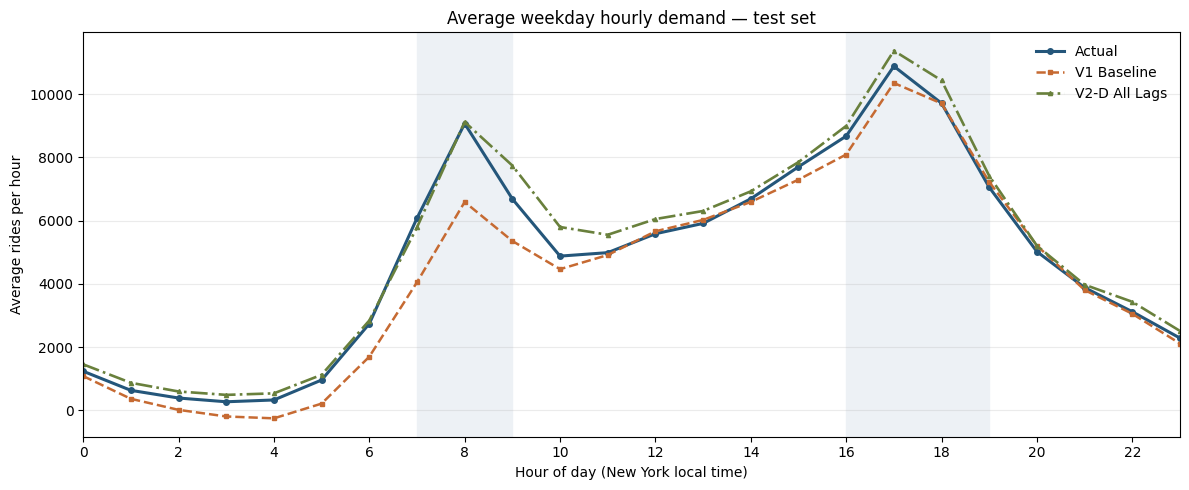

In [19]:
hourly_pattern = weekday_results.groupby("hour")[[
    "actual", "v1_prediction", "all_lags_prediction"
]].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(7, 9, color="#EDF1F5", zorder=0)
ax.axvspan(16, 19, color="#EDF1F5", zorder=0)
ax.plot(hourly_pattern.index, hourly_pattern["actual"], color="#24567A",
        marker="o", markersize=4, linewidth=2.2, label="Actual")
ax.plot(hourly_pattern.index, hourly_pattern["v1_prediction"], color="#C66A32",
        linestyle="--", marker="s", markersize=3, linewidth=1.8, label="V1 Baseline")
ax.plot(hourly_pattern.index, hourly_pattern["all_lags_prediction"], color="#69803C",
        linestyle="-.", marker="^", markersize=3, linewidth=1.9, label="V2-D All Lags")
ax.set(title="Average weekday hourly demand — test set",
       xlabel="Hour of day (New York local time)", ylabel="Average rides per hour")
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**图后观察：**V2-D 的工作日平均曲线在 08:00 更贴近真实高峰；17:00 附近则略高于真实均值。凌晨低需求时段，V1 平均预测偏低甚至为负，V2-D 的形状更接近真实曲线。高峰的量化误差见第 15 节。


## 17. Seven-Day Prediction Comparison

选择与 03 相同的测试集连续七天：**2024-10-21 至 2024-10-27**。三条曲线对比真实需求、V1 与 V2-D；这张图帮助观察逐小时变化，整体结论仍以全部测试小时的指标为准。


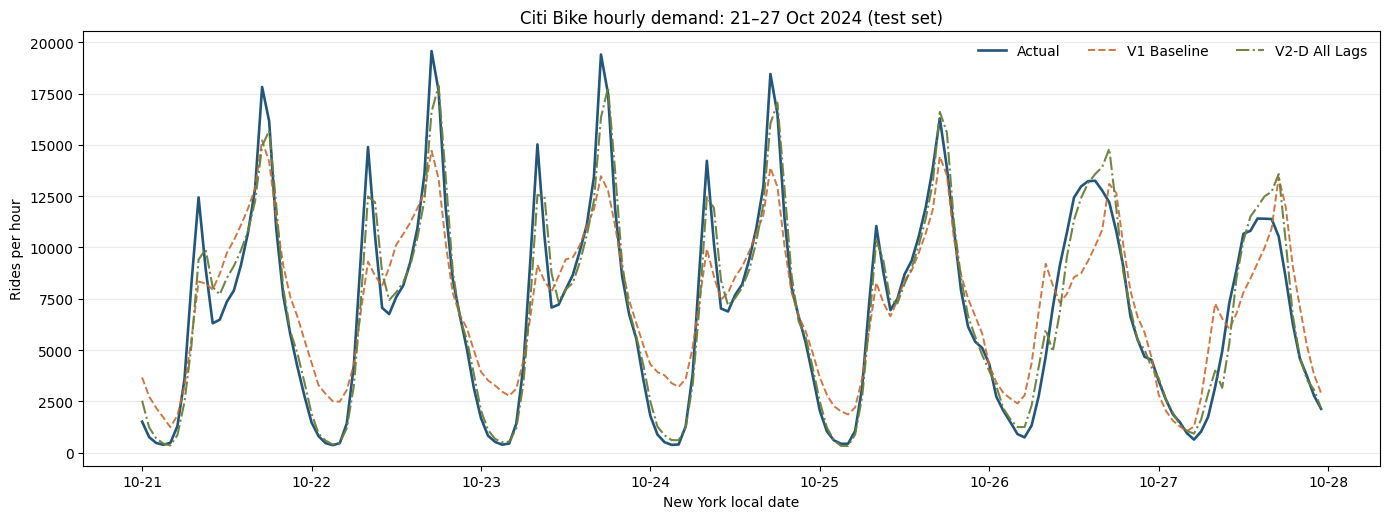

In [20]:
week_start = pd.Timestamp("2024-10-21 00:00")
week_end = week_start + pd.Timedelta(days=7)
one_week = results.loc[
    results["timestamp"].ge(week_start) & results["timestamp"].lt(week_end)
]
assert len(one_week) == 7 * 24
assert one_week["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()

fig, ax = plt.subplots(figsize=(14, 5.3))
ax.plot(one_week["timestamp"], one_week["actual"], color="#24567A",
        linewidth=1.9, label="Actual")
ax.plot(one_week["timestamp"], one_week["v1_prediction"], color="#C66A32",
        linestyle="--", linewidth=1.4, alpha=0.9, label="V1 Baseline")
ax.plot(one_week["timestamp"], one_week["all_lags_prediction"], color="#69803C",
        linestyle="-.", linewidth=1.5, alpha=0.95, label="V2-D All Lags")
ax.set(title="Citi Bike hourly demand: 21–27 Oct 2024 (test set)",
       xlabel="New York local date", ylabel="Rides per hour")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()


**图后观察：**这一周里 V2-D 对多次工作日尖峰和夜间低谷的跟随更紧，但仍有个别小时高估或低估。单周图只作形状检查，模型优劣以第 13 节全部 1,757 个测试小时的结果为准。


## 18. Negative Prediction Analysis

需求不可能小于零，但普通 `LinearRegression` 没有非负约束。这里统计五个模型在**相同测试小时**里的负预测数量，保留原始预测，不做 `clip()`。


In [21]:
negative_results = pd.DataFrame({
    "Model": list(predictions.keys()),
    "Negative predictions": [int((prediction < 0).sum()) for prediction in predictions.values()],
    "Test hours": len(y_test),
}).set_index("Model")
display(negative_results)


,Negative predictions,Test hours
Model,,
V1 Baseline,258,1757
V2-A + lag_1,121,1757
V2-B + lag_24,159,1757
V2-C + lag_168,93,1757
V2-D + all lags,28,1757


**本次观察：**负预测值从 V1 的 **258** 个减少到 V2-D 的 **28** 个，但没有完全消失。保留这些原始负值，才能看清线性回归的输出限制。


## 19. Lag Correlation and Coefficients

相关系数表使用**训练期**且三个 lag 都完整的小时。它描述历史需求与当前需求的共同变化，帮助理解特征可能有用的原因；相关性不是因果关系。


In [22]:
correlation_data = model_data.loc[train_mask, ["ride_count", *lag_columns]].dropna()
lag_correlation = correlation_data.corr()
print(f"相关系数使用的训练小时: {len(correlation_data):,}")
display(lag_correlation.round(3))


相关系数使用的训练小时: 6,857


,ride_count,lag_1,lag_24,lag_168
ride_count,1.000,0.912,0.882,0.893
lag_1,0.912,1.000,0.813,0.817
lag_24,0.882,0.813,1.000,0.852
lag_168,0.893,0.817,0.852,1.000


V2-D 的 lag coefficient 表示：**在模型中其他已加入特征保持不变时**，该 lag 增加 1 次骑行，线性预测值大约变化多少次骑行。三个 lag 之间可能相关，单独解释系数要谨慎；系数不代表严格因果效应。


In [23]:
all_lag_coefficients = pd.Series(model_all_lags.coef_, index=features_all_lags)
lag_coefficient_table = all_lag_coefficients.loc[lag_columns].to_frame("Coefficient")
display(lag_coefficient_table.round(4))


,Coefficient
lag_1,0.6598
lag_24,0.1215
lag_168,0.1959


## 20. What Did We Learn?

下面根据本次运行的指标自动生成结论，避免提前写死哪一个 lag 最好。判断“有效”时先看 MAE，同时参考 RMSE 与 R²；单个测试时段的结果不等于普遍规律。


In [24]:
all_lags_row = model_comparison.loc["V2-D + all lags"]
best_single_row = model_comparison.loc[best_single_mae]
morning_v1 = peak_comparison.loc[("Morning 07–09", "V1 Baseline")]
morning_all = peak_comparison.loc[("Morning 07–09", "V2-D + all lags")]
evening_v1 = peak_comparison.loc[("Evening 16–19", "V1 Baseline")]
evening_all = peak_comparison.loc[("Evening 16–19", "V2-D + all lags")]
negative_v1 = negative_results.loc["V1 Baseline", "Negative predictions"]
negative_all = negative_results.loc["V2-D + all lags", "Negative predictions"]

lag_lines = []
for label, name, meaning in [
    ("lag_1", "V2-A + lag_1", "短期惯性"),
    ("lag_24", "V2-B + lag_24", "日周期"),
    ("lag_168", "V2-C + lag_168", "周周期"),
]:
    row = model_comparison.loc[name]
    direction = "改善" if row["MAE Improvement vs V1"] > 0 else "未改善"
    lag_lines.append(
        f"- **{label}（{meaning}）**：MAE {row['MAE']:,.2f}，"
        f"RMSE {row['RMSE']:,.2f}，R² {row['R²']:.3f}；"
        f"相对 V1 的 MAE {direction} {abs(row['MAE Improvement vs V1']):,.2f} 次/小时。"
    )

morning_bias_change = abs(morning_v1["Mean Error"]) - abs(morning_all["Mean Error"])
evening_bias_change = abs(evening_v1["Mean Error"]) - abs(evening_all["Mean Error"])
morning_verdict = "减轻" if morning_bias_change > 0 else "没有减轻"
evening_verdict = "减轻" if evening_bias_change > 0 else "没有减轻"
all_vs_single = "进一步降低" if all_lags_row["MAE"] < best_single_row["MAE"] else "没有进一步降低"

display(Markdown("\n\n".join([
    "**1–3. 三个 lag 各自是否有效？**",
    *lag_lines,
    f"**4. 最有效的单独 lag：**按 MAE 是 **{best_single_mae}**；按 RMSE 是 **{best_single_rmse}**。",
    f"**5. 三个一起：**V2-D 的 MAE 为 **{all_lags_row['MAE']:,.2f}**，相对最佳单独 lag {all_vs_single} MAE。",
    f"**6. V1 vs V2-D：**MAE {v1_mae:,.2f} → {all_lags_row['MAE']:,.2f}，"
    f"改善 **{all_lags_row['MAE Improvement vs V1']:,.2f}** 次/小时（{all_lags_row['MAE Improvement %']:.2f}%）；"
    f"RMSE {v1_rmse:,.2f} → {all_lags_row['RMSE']:,.2f}，"
    f"改善 **{all_lags_row['RMSE Improvement vs V1']:,.2f}**（{all_lags_row['RMSE Improvement %']:.2f}%）；"
    f"R² {v1_r2:.3f} → {all_lags_row['R²']:.3f}，变化 **{all_lags_row['R² Improvement vs V1']:+.3f}**。",
    f"**7. 早高峰：**平均误差 {morning_v1['Mean Error']:+,.1f} → {morning_all['Mean Error']:+,.1f}；"
    f"MAE {morning_v1['MAE']:,.1f} → {morning_all['MAE']:,.1f}。平均偏差的绝对值{morning_verdict}。",
    f"**8. 晚高峰：**平均误差 {evening_v1['Mean Error']:+,.1f} → {evening_all['Mean Error']:+,.1f}；"
    f"MAE {evening_v1['MAE']:,.1f} → {evening_all['MAE']:,.1f}。平均偏差的绝对值{evening_verdict}。",
    f"**9. 负预测：**V1 为 **{negative_v1}** 个，V2-D 为 **{negative_all}** 个；各单 lag 数量见第 18 节。",
    "**10. 历史需求为何有帮助？**日历与天气不能直接告诉模型上一小时、昨天或上周的实际需求。lag 把这些已发生的水平和重复模式带入特征，让模型能针对近期状态调整预测。具体贡献以本次消融指标为准。",
    "**11. 当前限制：**线性加法模型仍难表达复杂的非线性和时段交互，也可能输出负需求。V2 各模型损失的训练开头行数不同，因此主比较含少量训练窗口变化。训练期未覆盖 11、12 月；当前天气是历史观测。夏令时附近的春季占位行和秋季合并行可能成为 lag 来源，需谨慎解释。",
])))


**1–3. 三个 lag 各自是否有效？**

- **lag_1（短期惯性）**：MAE 777.45，RMSE 1,090.82，R² 0.922；相对 V1 的 MAE 改善 736.45 次/小时。

- **lag_24（日周期）**：MAE 1,105.46，RMSE 1,529.23，R² 0.846；相对 V1 的 MAE 改善 408.44 次/小时。

- **lag_168（周周期）**：MAE 1,131.78，RMSE 1,546.52，R² 0.843；相对 V1 的 MAE 改善 382.12 次/小时。

**4. 最有效的单独 lag：**按 MAE 是 **V2-A + lag_1**；按 RMSE 是 **V2-A + lag_1**。

**5. 三个一起：**V2-D 的 MAE 为 **745.08**，相对最佳单独 lag 进一步降低 MAE。

**6. V1 vs V2-D：**MAE 1,513.90 → 745.08，改善 **768.82** 次/小时（50.78%）；RMSE 1,956.46 → 1,031.98，改善 **924.47**（47.25%）；R² 0.748 → 0.930，变化 **+0.182**。

**7. 早高峰：**平均误差 +1,946.7 → -272.2；MAE 2,696.5 → 1,389.4。平均偏差的绝对值减轻。

**8. 晚高峰：**平均误差 +237.0 → -474.1；MAE 2,131.2 → 1,074.0。平均偏差的绝对值没有减轻。

**9. 负预测：**V1 为 **258** 个，V2-D 为 **28** 个；各单 lag 数量见第 18 节。

**10. 历史需求为何有帮助？**日历与天气不能直接告诉模型上一小时、昨天或上周的实际需求。lag 把这些已发生的水平和重复模式带入特征，让模型能针对近期状态调整预测。具体贡献以本次消融指标为准。

**11. 当前限制：**线性加法模型仍难表达复杂的非线性和时段交互，也可能输出负需求。V2 各模型损失的训练开头行数不同，因此主比较含少量训练窗口变化。训练期未覆盖 11、12 月；当前天气是历史观测。夏令时附近的春季占位行和秋季合并行可能成为 lag 来源，需谨慎解释。

## 21. Next Step

现在分别检验了 **Feature Representation（时间 One-Hot）** 与 **Historical Lag Features（历史需求）** 对同一线性模型的影响。下一阶段才考虑 **Model Choice**，可以在固定数据、特征和测试时段后尝试 Random Forest 或 Gradient Boosting；本 Notebook 不训练树模型，也不增加 rolling 特征。

如果目标改成**一次性预测未来 7 天**，未来区间内部的真实 `ride_count` 当时尚未发生，不能直接作为 lag。那需要递归预测，或重新设计多步预测输入与评估。本阶段只评估逐小时滚动、之前真实需求已知的情景。
